# **Integral Equations**

In the following we shall find a solution for the integral equation $\varphi(x) = 1 + \frac{1}{2}\int_0^1 e^{-xt} \varphi(t) dt$ using neural networks.

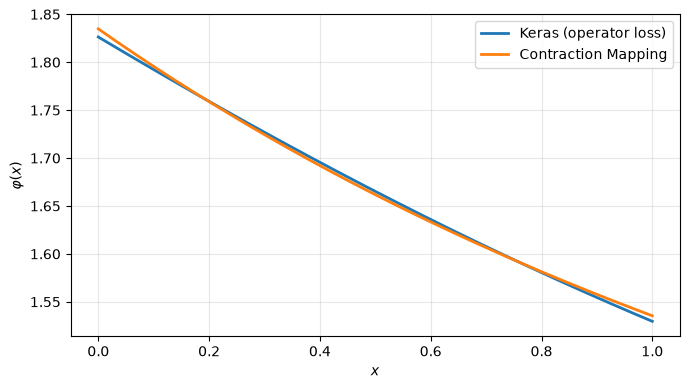

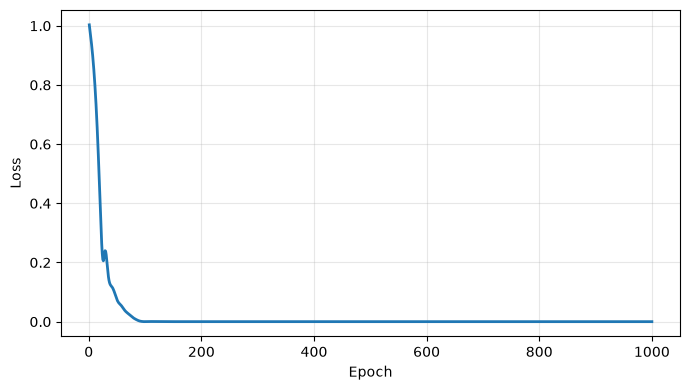

[NN ] phi(0) ≈ 1.8262960336,   phi(1) ≈ 1.5296536797
[CM ] phi(0) ≈ 1.8347584076,   phi(1) ≈ 1.5354450446


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


# Repro & dtype
np.random.seed(0)
tf.random.set_seed(0)
DTYPE = tf.float64
tf.keras.backend.set_floatx('float64')

# Grids & Quadrature (trapezoid on [0,1])
M = 4001                               # quadrature points for t in [0,1]
t_grid_np = np.linspace(0.0, 1.0, M).reshape(-1, 1)   # (M,1)
w_np = np.ones((M, 1))
w_np[0] = 0.5
w_np[-1] = 0.5
w_np *= 1.0 / (M - 1)                  # Δt (trapezoid weights)

t_grid = tf.constant(t_grid_np, dtype=DTYPE)   # (M,1)
w = tf.constant(w_np, dtype=DTYPE)             # (M,1)

# For plotting / comparing both methods
X_PLOT = np.linspace(0.0, 1.0, 1000).reshape(-1, 1).astype(np.float64)


# Contraction Mapping solution (discretized)
# φ_{k+1}(x_i) = 1 + 1/2 * ∑_j e^{-x_i t_j} φ_k(t_j) w_j

def contraction_mapping_solution(n_t=2001, tol=1e-10, max_iter=10000):
    t = np.linspace(0.0, 1.0, n_t)
    x = t.copy()
    # trapezoid weights on [0,1]
    w = np.ones_like(t)
    w[0] = 0.5
    w[-1] = 0.5
    w *= 1.0 / (n_t - 1)
    K = np.exp(-np.outer(x, t))            # (n_t, n_t)
    phi = np.zeros_like(t)                 # φ_0 = 0
    for _ in range(max_iter):
        I = K @ (phi * w)                  # integral at each x_i
        phi_new = 1.0 + 0.5 * I
        if np.max(np.abs(phi_new - phi)) < tol:
            phi = phi_new
            break
        phi = phi_new
    # Interpolate to X_PLOT for comparison
    phi_plot = np.interp(X_PLOT[:,0], x, phi)
    return phi_plot

phi_cm_plot = contraction_mapping_solution()


# Keras model φ(x) with operator loss
# residual(x) = φ(x) - 1 - 1/2 * ∫_0^1 e^{-x t} φ(t) dt
# We'll pass x through y_true so the loss has the batch's x values.

model = Sequential([
    Input(shape=(1,), dtype=DTYPE),
    Dense(64, activation='swish', dtype=DTYPE),
    Dense(64, activation='swish', dtype=DTYPE),
    Dense(64, activation='swish', dtype=DTYPE),
    Dense(64, activation='swish', dtype=DTYPE),
    Dense(64, activation='swish', dtype=DTYPE),
    Dense(1, dtype=DTYPE)
])

def g(x):  # g(x) = 1
    return tf.ones_like(x, dtype=DTYPE)

@tf.function
def integral_loss(y_true, y_pred):
    f_x = tf.cast(y_pred, DTYPE)                    # φ(x) at batch points (B,1)

    # Evaluate φ(t) at quadrature nodes (M,1) once per batch
    f_t = model(t_grid)

    # Kernel e^{-x t}: (B,1) @ (1,M) -> (B,M)
    x_batch = tf.reshape(tf.cast(y_true, DTYPE), (-1, 1))      # (B,1)
    X_times_T = tf.matmul(x_batch, tf.transpose(t_grid))       # (B,M)
    K = tf.exp(-X_times_T)                                     # (B,M)

    # Weighted integral per x_i: (B,M) @ (M,1) -> (B,1)
    integral = tf.matmul(K, f_t * w)

    residual = f_x - g(x_batch) - 0.5 * integral
    return tf.reduce_mean(tf.square(residual))

model.compile(optimizer=Adam(1e-3), loss=integral_loss)


# Training data and training
N = 1000
x_train = np.linspace(0.0, 1.0, N).reshape(-1, 1).astype(np.float64)
y_passthrough = x_train.copy()  # pass x as y_true so loss can read it

EPOCHS = 1000
history = model.fit(
    x_train, y_passthrough,
    epochs=EPOCHS,
    batch_size=len(x_train),    # full-batch due to coupling across x
    verbose=0
).history


# Predict NN solution on X_PLOT
phi_nn_plot = model.predict(X_PLOT, verbose=0)


# Plot both solutions on the same figure
plt.figure(figsize=(7, 4))
plt.plot(X_PLOT, phi_nn_plot, linewidth=2, label="Keras (operator loss)")
plt.plot(X_PLOT, phi_cm_plot, linewidth=2, label="Contraction Mapping")
plt.xlabel("$x$")
plt.ylabel("$\\varphi(x)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Plot loss vs epochs
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, EPOCHS+1), history['loss'], linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print key values for both methods
print(f"[NN ] phi(0) ≈ {phi_nn_plot[0,0]:.10f},   phi(1) ≈ {phi_nn_plot[-1,0]:.10f}")
print(f"[CM ] phi(0) ≈ {phi_cm_plot[0]:.10f},   phi(1) ≈ {phi_cm_plot[-1]:.10f}")


Check the error between the NN-solution and the Contraction Principle-solution.

In [3]:
# residual r(x) = φ_nn(x) - 1 - 1/2 * ∫ e^{-x t} φ_nn(t) dt
f_t = model(t_grid)                               # (M,1)
KxT = np.exp(-X_PLOT @ t_grid_np.T)               # (B,M)
integral = KxT @ (f_t.numpy() * w_np)             # (B,1)
r = phi_nn_plot - 1.0 - 0.5 * integral
print("NN residual: max |r| =", float(np.max(np.abs(r))))


NN residual: max |r| = 0.008440662861644799


 **An ill-posed problem**

Consider the Poisson kernel defined by
$
K(r,\theta) = \frac{1-r^2}{1-2r\cos\theta+r^2},
$
for $\theta \in [0,2\pi]$ and $0 \le r < 1$.

 We wish to find a function $\varphi: [0,2\pi] \to \mathbb{R}$ that satisfies the integral equation
$
\int_0^{2\pi} K(r,\theta) \, \varphi(\theta) \, d\theta = r.
$

Epoch 1/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 93s 3s/step - loss: 0.4059
Epoch 2/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - loss: 0.0935
Epoch 3/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - loss: 0.0847
Epoch 4/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - loss: 0.0844
Epoch 5/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - loss: 0.0844
Epoch 6/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - loss: 0.0844
Epoch 7/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - loss: 0.0844
Epoch 8/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - loss: 0.0844
Epoch 9/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - loss: 0.0844
Epoch 10/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - loss: 0.0844
Epoch 11/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - loss: 0.0843
Epoch 12/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - loss: 0.0843
Epoch 13/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - loss: 0.0843
Epoch 14/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - loss: 0.0843
Epoch 15/40
32/32 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - loss: 0.0843
Epoch 16/40
32/32 ━

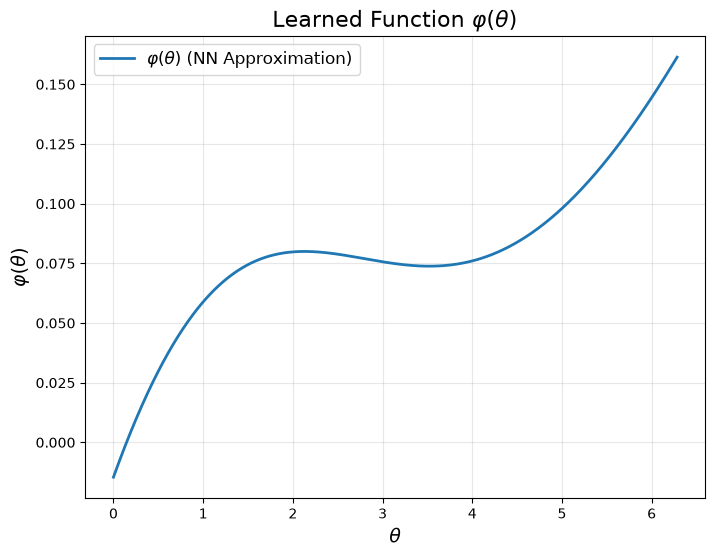

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras import Input

# Define the Poisson kernel using TensorFlow operations
def poisson_kernel(r, theta):
    return (1 - r**2) / (1 - 2 * r * tf.cos(theta) + r**2)

# Define the target function f(r) = r
def f_target(r):
    return r

# Generate training data: sample theta values uniformly in [0, 2π]
theta_vals = np.linspace(0, 2*np.pi, 4000).reshape(-1, 1)
# Use a uniform Riemann sum for integration over theta in [0,2π]
dtheta = (2*np.pi) / len(theta_vals)

# Build the neural network model to approximate φ(θ)
model = Sequential([
    Dense(40, activation='swish'),
    Dense(20, activation='tanh'),
    #Dense(20, activation='tanh'),
    #Dense(40, activation='swish'),
    Dense(1)
])

# Generate a set of r values in [0,1] for evaluating the loss function
r_samples = np.linspace(0, 1, 5000, endpoint=False).reshape(-1,1)

# Convert theta_vals to a TensorFlow constant (for integration purposes)
theta_tensor = tf.constant(theta_vals, dtype=tf.float64)

# Define a custom loss function based on the integral equation:
# For each r in r_samples, we approximate the integral
#    I(r) = ∫₀^(2π) K(r,θ) φ(θ) dθ,
# and enforce I(r) ≈ f_target(r) = r.
def custom_loss(y_true, y_pred):
    # y_true is a dummy variable.
    # Evaluate the network on the fixed integration points (theta_vals) to obtain φ(θ).
    phi_vals = model(theta_tensor)  # shape: (1000, 1)

    # Define a function to compute the approximate integral for a given r.
    def compute_integral(r):
        # r is a scalar tensor of shape (1,)
        # Compute the kernel at all theta for the given r.
        # Use tf.reshape to ensure correct dimensions.
        kernel_vals = poisson_kernel(r[0], tf.reshape(theta_tensor, [-1]))  # shape: (1000,)
        kernel_vals = tf.reshape(kernel_vals, [-1, 1])  # shape: (1000, 1)
        # Compute the Riemann sum for the integral.
        integral_val = dtheta * tf.reduce_sum(kernel_vals * phi_vals)
        return integral_val

    # Convert r_samples to a tensor.
    r_tensor = tf.constant(r_samples, dtype=tf.float64)  # shape: (50, 1)
    # Apply the compute_integral function to each r using tf.map_fn.
    integrals = tf.map_fn(compute_integral, r_tensor)  # shape: (50, 1)

    # The residual for each r is the difference between the approximate integral and r.
    residuals = integrals - r_tensor
    # The loss is the mean squared residual.
    loss_value = tf.reduce_mean(tf.square(residuals))
    return loss_value

# Compile the model using the Adam optimizer
model.compile(optimizer=Adam(learning_rate=0.005), loss=custom_loss)

# Create dummy training data; note that the loss is computed solely from theta_vals and r_samples.
dummy_input = np.zeros((1000, 1))
dummy_target = np.zeros((1000, 1))

# Train the model for 500 epochs.
model.fit(dummy_input, dummy_target, epochs=40, batch_size=32, verbose=1)

# After training, evaluate the learned function φ(θ) on a dense grid for visualization.
theta_plot = np.linspace(0, 2*np.pi, 1000).reshape(-1, 1)
phi_learned = model.predict(theta_plot)

# Plot the learned function φ(θ)
plt.figure(figsize=(8,6))
plt.plot(theta_plot, phi_learned, label=r"$\varphi(\theta)$ (NN Approximation)", linewidth=2)
plt.title(r"Learned Function $\varphi(\theta)$", fontsize=16)
plt.xlabel(r"$\theta$", fontsize=14)
plt.ylabel(r"$\varphi(\theta)$", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()
